In [164]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from copy import deepcopy
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
sns.set_theme()

# Первый взгляд на набор данных

In [2]:
(uni15 := pd.read_excel("result2015.xlsx"))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,100.00,0.00,96.00,95.00,43,14,0,0.00,35.26,35.26,...,89.50,10.40,96.10,26.24,Негосударственное образовательное учреждение в...,г.Москва,Частные образовательные организации,http://www.nes.ru/,2078,2015
1,0.00,0.00,50.74,37.26,0,0,0,0.00,12.58,12.81,...,51.29,0.31,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,http://www.odinuni.ru,110353,2015
2,69.83,69.83,58.49,46.33,0,0,9,6.08,5.41,9.80,...,53.20,13.80,4.71,25.59,государственное бюджетное образовательное учре...,г.Москва,Муниципалитеты и субъекты РФ,http://www.asou-mo.ru,110145,2015
3,70.81,70.81,77.50,53.12,0,0,0,0.00,0.00,2.27,...,54.90,0.00,3.10,0.00,федеральное государственное бюджетное образова...,г.Москва,Министерство культуры Российской Федерации,http://www.axu.ru,1651,2015
4,0.00,0.00,48.56,48.00,0,0,0,0.00,0.00,0.00,...,93.99,6.01,100.00,100.00,Аккредитованное образовательное учреждение выс...,г.Москва,Частные образовательные организации,http://www.masi.ru/,2011,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707

In [3]:
(uni20 := pd.read_excel("result2020.xlsx"))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,0.00,0.00,60.63,46.54,0,0,0,0.00,0.00,0.00,...,86.83,4.41,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2020
1,59.04,59.04,51.41,45.26,0,0,0,0.00,0.00,0.00,...,67.01,11.92,36.46,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2020
2,0.00,0.00,0.00,0.00,0,0,0,0.00,2.14,2.14,...,94.99,5.01,80.46,100.00,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,niddesign.ru,1944,2020
3,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,77.50,11.82,100.00,100.00,автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2020
4,0.00,0.00,55.30,55.30,0,0,0,0.00,0.00,0.00,...,43.53,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2020
...,...,...,...,...,...,...,

In [4]:
(uni21 := pd.read_excel("result2021.xlsx"))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,0.00,0.00,60.45,50.04,0,0,0,0.00,4.63,4.63,...,79.74,3.24,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2021
1,52.23,52.23,47.49,42.24,0,0,0,0.00,0.00,0.00,...,69.83,8.52,34.25,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2021
2,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,92.60,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2021
3,0.00,0.00,52.80,52.80,0,0,0,0.00,0.00,0.00,...,68.08,19.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2021
4,0.00,0.00,0.00,0.00,0,0,0,0.00,100.00,100.00,...,8.20,86.07,4.09,12.46,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2021
...,...,...,...,...,..

In [5]:
(uni22 := pd.read_excel("result2022.xlsx"))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,0.00,0.00,61.28,48.28,0,0,0,0.00,8.34,8.34,...,80.76,4.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2022
1,51.69,51.69,51.48,39.26,0,0,0,0.00,0.00,0.00,...,66.01,11.19,34.13,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2022
2,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,97.58,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2022
3,0.00,0.00,55.70,55.70,0,0,0,0.00,0.00,0.00,...,68.66,1.53,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2022
4,0.00,0.00,0.00,0.00,0,0,0,0.00,100.00,100.00,...,9.09,85.08,9.77,12.17,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2022
...,...,...,...,...,..

# Объединение таблиц и удаление незначащих столбцов

In [6]:
for col_index, col15, col20, col21, col22 in zip(
    range(len(uni15.columns)), uni15.columns, uni20.columns, uni21.columns, uni22.columns
):
    print(f"Заголовки столбца {col_index}: {"" if col15 == col20 == col21 == col22 else "не"}одинаковые")
    print(col15, col20, col21, col22, sep="\n", end="\n\n")

Заголовки столбца 0: одинаковые
Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ
Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ
Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ
Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ

Заголовки столбца 1: одинаковые
Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетно

In [7]:
uni20.columns = uni15.columns
uni21.columns = uni15.columns
uni22.columns = uni15.columns
(uni := pd.concat([uni15, uni20, uni21, uni22], ignore_index=True))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,100.00,0.00,96.00,95.00,43,14,0,0.00,35.26,35.26,...,89.50,10.40,96.10,26.24,Негосударственное образовательное учреждение в...,г.Москва,Частные образовательные организации,http://www.nes.ru/,2078,2015
1,0.00,0.00,50.74,37.26,0,0,0,0.00,12.58,12.81,...,51.29,0.31,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,http://www.odinuni.ru,110353,2015
2,69.83,69.83,58.49,46.33,0,0,9,6.08,5.41,9.80,...,53.20,13.80,4.71,25.59,государственное бюджетное образовательное учре...,г.Москва,Муниципалитеты и субъекты РФ,http://www.asou-mo.ru,110145,2015
3,70.81,70.81,77.50,53.12,0,0,0,0.00,0.00,2.27,...,54.90,0.00,3.10,0.00,федеральное государственное бюджетное образова...,г.Москва,Министерство культуры Российской Федерации,http://www.axu.ru,1651,2015
4,0.00,0.00,48.56,48.00,0,0,0,0.00,0.00,0.00,...,93.99,6.01,100.00,100.00,Аккредитованное образовательное учреждение выс...,г.Москва,Частные образовательные организации,http://www.masi.ru/,2011,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275

In [8]:
uni_cols_index_to_drop = [61, 62, 75, 87, 97, 107, 116, 117]
uni.iloc[:, uni_cols_index_to_drop]

,2,Образовательная деятельность,Научная деятельность,Кадровый потенциал,Международная деятельность,Инфраструктура,Наличие электронной библиотечной системы,Финансово-экономическая деятельность
0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2755,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2756,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2757,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2758,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
(uni := uni.drop(uni.columns[uni_cols_index_to_drop], axis=1))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,100.00,0.00,96.00,95.00,43,14,0,0.00,35.26,35.26,...,89.50,10.40,96.10,26.24,Негосударственное образовательное учреждение в...,г.Москва,Частные образовательные организации,http://www.nes.ru/,2078,2015
1,0.00,0.00,50.74,37.26,0,0,0,0.00,12.58,12.81,...,51.29,0.31,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,http://www.odinuni.ru,110353,2015
2,69.83,69.83,58.49,46.33,0,0,9,6.08,5.41,9.80,...,53.20,13.80,4.71,25.59,государственное бюджетное образовательное учре...,г.Москва,Муниципалитеты и субъекты РФ,http://www.asou-mo.ru,110145,2015
3,70.81,70.81,77.50,53.12,0,0,0,0.00,0.00,2.27,...,54.90,0.00,3.10,0.00,федеральное государственное бюджетное образова...,г.Москва,Министерство культуры Российской Федерации,http://www.axu.ru,1651,2015
4,0.00,0.00,48.56,48.00,0,0,0,0.00,0.00,0.00,...,93.99,6.01,100.00,100.00,Аккредитованное образовательное учреждение выс...,г.Москва,Частные образовательные организации,http://www.masi.ru/,2011,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275

In [10]:
uni_T = uni.T
uni[uni_T.index[uni_T.duplicated(keep=False)]]

,"Объем средств, полученных образовательной организацией на выполнение НИОКР от иностранных граждан и иностранных юридических лиц","Объем средств от образовательной деятельности, полученных образовательной организацией от иностранных граждан и иностранных юридических лиц",Доходы вуза из иностранных источников на выполнение НИОКР,Доходы вуза от образовательной деятельности из иностранных источников
0,906.0,47333.5,906.0,47333.5
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
2755,0.0,33947.4,0.0,33947.4
2756,0.0,40146.1,0.0,40146.1
2757,0.0,0.0,0.0,0.0
2758,0.0,0.0,0.0,0.0


In [11]:
(uni := uni.drop(columns=uni_T.index[uni_T.duplicated(keep="last")]))

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,100.00,0.00,96.00,95.00,43,14,0,0.00,35.26,35.26,...,89.50,10.40,96.10,26.24,Негосударственное образовательное учреждение в...,г.Москва,Частные образовательные организации,http://www.nes.ru/,2078,2015
1,0.00,0.00,50.74,37.26,0,0,0,0.00,12.58,12.81,...,51.29,0.31,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,http://www.odinuni.ru,110353,2015
2,69.83,69.83,58.49,46.33,0,0,9,6.08,5.41,9.80,...,53.20,13.80,4.71,25.59,государственное бюджетное образовательное учре...,г.Москва,Муниципалитеты и субъекты РФ,http://www.asou-mo.ru,110145,2015
3,70.81,70.81,77.50,53.12,0,0,0,0.00,0.00,2.27,...,54.90,0.00,3.10,0.00,федеральное государственное бюджетное образова...,г.Москва,Министерство культуры Российской Федерации,http://www.axu.ru,1651,2015
4,0.00,0.00,48.56,48.00,0,0,0,0.00,0.00,0.00,...,93.99,6.01,100.00,100.00,Аккредитованное образовательное учреждение выс...,г.Москва,Частные образовательные организации,http://www.masi.ru/,2011,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275

In [12]:
uni.rename(columns={
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ":
        "avg_ege_fulltime_budget",
    "Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема":
        "avg_ege_fulltime_budget_general",
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами":
        "avg_ege_fulltime_paid",
    "Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета":
        "avg_min_ege_per_program_fulltime",
    "Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний":
        "students_vseros_team_bvi",
    "Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний":
        "students_other_olymp_bvi",
    "Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета":
        "students_target_admission",
    "Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения":
        "target_admission_share",
    "Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры":
        "master_fte_share_of_total_fte",
    "Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования":
        "master_phd_fte_share_total_fte",
    "Удельный вес численности студентов, имеющих диплом бакалавра, специалиста или магистра других организаций, принятых на первый курс на обучение по программам магистратуры образовательной организации, в общей численности студентов, принятых на первый курс по программам магистратуры на очную форму обучения":
        "master_admitted_from_other_uni_share",
    "Удельный вес численности обучающихся по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре":
        "master_phd_from_other_uni_share",
    "Численность аспирантов образовательной организации в расчете на 100 студентов (приведенного контингента)":
        "phd_students_per_100_fte",
    "Удельный вес численности слушателей из сторонних организаций в общей численности слушателей, прошедших обучение в образовательной организации по программам повышения квалификации или профессиональной переподготовки":
        "dpo_external_listeners_share",
    "Удельный вес численности студентов, обучающихся по направлениям подготовки бакалавриата, специалитета, и магистратуры по областям знаний «Инженерное дело, технологии и технические науки», «Здравоохранение и медицинские науки», «Образование и педагогические науки», с которыми заключены договоры о целевом обучении, в общей численности студентов, обучающихся по указанным областям знаний":
        "target_enrollment_tech_med_edu_share",


    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science в расчете на 100 НПР":
        "citations_wos_per_100_faculty_5y",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Scopus в расчете на 100 НПР":
        "citations_scopus_per_100_faculty_5y",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в Российском индексе научного цитирования (далее – РИНЦ) в расчете на 100 НПР":
        "citations_rsci_per_100_faculty_5y",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science, в расчете на 100 НПР":
        "publications_wos_per_100_faculty_5y",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Scopus, в расчете на 100 НПР":
        "publications_scopus_per_100_faculty_5y",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования РИНЦ, в расчете на 100 НПР":
        "publications_rsci_per_100_faculty_5y",
    "Общий объем научно-исследовательских и опытно-конструкторских работ (далее – НИОКР)":
        "total_rnd_income",
    "Удельный вес доходов от НИОКР в общих доходах образовательной организации":
        "rnd_income_share_of_total_income",
    "Удельный вес НИОКР, выполненных собственными силами (без привлечения соисполнителей), в общих доходах образовательной организации от НИОКР":
        "inhouse_rnd_share_of_total_rnd",
    "Доходы от НИОКР (за исключением средств бюджетов бюджетной системы Российской Федерации, государственных фондов поддержки науки) в расчете на одного НПР":
        "extrabudgetary_rnd_income_per_faculty",
    "Количество лицензионных соглашений":
        "license_agreements_cnt",
    "Удельный вес средств, полученных образовательной организацией от использования результатов интеллектуальной деятельности, в общих доходах образовательной организации":
        "rid_income_share",
    "Удельный вес численности НПР без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности НПР":
        "young_faculty_share_by_degree_age",
    "Удельный вес научно-педагогических работников, защитивших кандидатские и докторские диссертации за отчетный период в общей численности НПР":
        "faculty_defended_dissertations_share",
    "Количество научных журналов, в том числе электронных, издаваемых образовательной организацией":
        "scientific_journals_cnt",
    "Количество полученных грантов за отчетный год в расчете на 100 НПР":
        "grants_per_100_faculty_1y",


    "Удельный вес численности иностранных студентов (кроме стран Содружества Независимых Государств (далее – СНГ)), обучающихся программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)":
        "foreign_noncis_fte_share",
    "Удельный вес численности иностранных студентов из СНГ, обучающихся по программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)":
        "foreign_cis_fte_share",
    "Удельный вес численности иностранных студентов, завершивших освоение образовательных программ бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)":
        "foreign_graduates_fte_share",
    "Удельный вес численности иностранных студентов (кроме стран СНГ), завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)":
        "foreign_noncis_graduates_fte_share",
    "Удельный вес численности иностранных студентов из стран СНГ, завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)":
        "foreign_cis_graduates_fte_share",
    "Удельный вес численности студентов, обучающихся по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, прошедших обучение за рубежом не менее семестра (триместра), в общей численности студентов, обучающихся по очной форме обучения":
        "outbound_mobile_students_share_fulltime",
    "Численность студентов иностранных образовательных организаций, прошедших обучение в образовательной организации по образовательным по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, не менее семестра (триместра) в расчете на 100 студентов, обучающихся по очной форме обучения":
        "inbound_mobile_students_per_100_fulltime",
    "Удельный вес численности иностранных граждан из числа НПР в общей численности НПР":
        "foreign_faculty_share",
    "Численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих в образовательной организации не менее 1 семестра":
        "visiting_foreign_scholars_cnt",
    "Удельный вес численности иностранных граждан (кроме стран СНГ) из числа аспирантов образовательной организации в общей численности аспирантов":
        "foreign_noncis_phd_share",
    "Удельный вес численности иностранных граждан из стран СНГ из числа аспирантов образовательной организации в общей численности аспирантов":
        "foreign_cis_phd_share",


    "Доходы образовательной организации из средств от приносящей доход деятельности в расчете на одного НПР":
        "extrabudgetary_per_faculty",
    "Доля доходов из средств от приносящей доход деятельности в доходах по всем видам финансового обеспечения (деятельности) образовательной организации":
        "income_generating_share_of_total_income",
    "Отношение средней заработной платы НПР в образовательной организации (из всех источников) к средней заработной плате по экономике региона":
        "faculty_salary_to_regional_avg_ratio",
    "Доходы образовательной организации из всех источников в расчете на численность студентов (приведенный контингент)":
        "total_income_per_fte",
    "Общая площадь учебно-лабораторных помещений в расчете на одного студента (приведенного контингента),в том числе:":
        "lab_area_per_fte",
    "имеющихся на праве собственности":
        "lab_area_owned_per_fte",
    "закрепленных на праве оперативного управления":
        "lab_area_managed_per_fte",
    "предоставленных в безвозмездное пользование":
        "lab_area_free_use_per_fte",
    "предоставленных в аренду":
        "lab_area_leased_per_fte",
    "Количество персональных компьютеров в расчете на одного студента (приведенного контингента)":
        "pc_per_fte",
    "Удельный вес стоимости машин и оборудования (не старше 5 лет) в общей стоимости машин и оборудования":
        "pc_under_5y_share",
    "Количество экземпляров печатных учебных изданий (включая учебники и учебные пособия) из общего количества единиц хранения библиотечного фонда, состоящих на учете, в расчете на одного студента (приведенного контингента)":
        "books_per_fte",
    "Удельный вес НПР, имеющих ученую степень кандидата наук, в общей численности НПР":
        "candidate_share",
    "Удельный вес НПР имеющих ученую степень доктора наук, в общей численности НПР":
        "doctor_share",
    "Удельный вес НПР, имеющих ученую степень кандидата и доктора наук, в общей численности НПР образовательной организации (без совместителей и работающих по договорам гражданско-правового характера)":
        "candidate_doctor_core_faculty_share",
    "Число НПР, имеющих ученую степень кандидата и доктора наук, в расчете на 100 студентов":
        "candidate_doctor_per_100_students",
    "Доля штатных работников ППС в общей численности ППС":
        "fulltime_faculty_share",


    "Общая численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры":
        "total_students_bsm",
    "в том числе:по очной форме обучения":
        "total_students_bsm_fulltime",
    "по очно-заочной (вечерней) форме обучения":
        "total_students_bsm_parttime",
    "по заочной форме обучения":
        "total_students_bsm_correspondence",
    "Средний балл ЕГЭ студентов, принятых на обучение по программам бакалавриата и специалитета, по всем формам обучения":
        "avg_ege_admitted_bs",
    "Доля обучающихся по программам бакалавриата, специалитета, магистратуры в очной форме":
        "fulltime_bsm_share",
    "Доля обучающихся по программам бакалавриата в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры":
        "bachelor_of_bsm_share",
    "Доля обучающихся по программам магистратуры в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры":
        "master_of_bsm_share",
    "Общая численность слушателей программ дополнительного профессионального образования":
        "total_dpo_listeners",
    "Общая численность обучающихся по программам среднего профессионального образования":
        "total_spo_students",
    "Число предприятий, с которыми заключены договоры на подготовку специалистов":
        "enterprises_training_contracts_cnt",
    "Число предприятий, являющихся базами практики, с которыми оформлены договорные отношения":
        "enterprises_internship_bases_cnt",


    "Общий объем НИОКР, выполненных собственными силами":
        "inhouse_rnd_volume",
    "Общий объем работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами":
        "inhouse_scientific_services_volume",
    "Общее количество публикаций организации в расчете на 100 НПР":
        "publications_per_100_faculty",
    "Количество бизнес-инкубаторов":
        "business_incubators_cnt",
    "Количество технопарков":
        "technoparks_cnt",
    "Количество центров коллективного пользования научным оборудованием":
        "shared_research_facilities_cnt",
    "Количество малых предприятий":
        "small_enterprises_cnt",
    "Общая численность аспирантов":
        "total_phd_students",
    "Доля аспирантов, обучающихся в очной форме":
        "phd_students_fulltime_share",
    "Общая численность докторантов":
        "total_postdoc_students",
    "Число диссертационных советов":
        "dissertation_councils_cnt",


    "Общая численность работников образовательной организации (без внешних совместителей и работающих по договорам ГПХ)":
        "total_core_staff",
    "Общая численность ППС (без внешних совместителей и работающих по договорам ГПХ)":
        "total_core_faculty",
    "Общая численность научных работников (без внешних совместителей и работающих по договорам ГПХ)":
        "total_core_research_staff",
    "Доля ППС, имеющих ученые степени":
        "faculty_candidate_doctor_share",
    "Доля научных работников, имеющих ученые степени":
        "research_staff_candidate_doctor_share",
    "Доля ППС возрастной категории моложе 65 лет":
        "faculty_under_65y_share",
    "Доля ППС возрастной категории моложе 40 лет":
        "faculty_under_40y_share",
    "Средняя заработная плата ППС (без внешних совместителей и работающих по договорам ГПХ)":
        "avg_salary_core_faculty",
    "Средняя заработная плата научных работников (без внешних совместителей и работающих по договорам ГПХ)":
        "avg_salary_core_research_staff",


    "Общая численность иностранных студентов, обучающихся по программам бакалавриата, специалитета, магистратуры":
        "total_foreign_students_bsm",
    "Доля иностранных студентов в общей численности студентов, обучающихся по программам бакалавриата, специалитета, магистратуры":
        "foreign_students_bsm_share",
    "Общее число образовательных программ высшего образования, реализуемых совместно с зарубежными вузами и ведущих к получению двух дипломов":
        "double_degree_programs_cnt",
    "Общая численность обучающихся по очной форме обучения по программам бакалавриата, специалитета, магистратуры, реализуемым совместно с зарубежными вузами и ведущим к получению двух дипломов":
        "double_degree_students_fulltime_bsm",
    "Общая численность иностранных аспирантов":
        "total_foreign_phd_students",
    "Число статей, подготовленных совместно с зарубежными организациями":
        "publications_with_foreign_orgs_cnt",
    "Доходы вуза из иностранных источников на выполнение НИОКР":
        "foreign_rnd_income",
    "Доходы вуза от образовательной деятельности из иностранных источников":
        "foreign_educational_income",
    "Количество созданных результатов интеллектуальной деятельности, имеющих правовую охрану за пределами России":
        "rid_foreign_protected_cnt",


    "Общая площадь зданий (помещений)":
        "total_building_area",
    "Площадь учебно-лабораторных зданий":
        "educational_lab_building_area",
    "Площадь, предназначенная для научно-исследовательских подразделений":
        "research_facilities_area",
    "Площадь общежитий":
        "dormitory_area",
    "Площадь крытых спортивных сооружений":
        "indoor_sports_area",
    "Доля студентов, не обеспеченных собственным общежитием, в числе студентов, нуждающихся в общежитии":
        "dormitory_deficit_share",
    "Количество персональных компьютеров":
        "pc_total_cnt",
    "Доля персональных компьютеров, имеющих доступ к Интернету":
        "pc_internet_access_share",


    "Доходы вуза из всех источников":
        "total_income",
    "Доходы вуза из внебюджетных источников":
        "extrabudgetary_income",
    "Доля доходов вуза из внебюджетных источников":
        "extrabudgetary_share",
    "Доля доходов вуза из федерального бюджета":
        "federal_budget_share",
    "Доля доходов вуза из бюджета субъекта РФ и местного бюджета":
        "regional_local_budget_share",
    "Доля доходов вуза от образовательной деятельности в общих доходах вуза":
        "educational_income_share",
    "Доля доходов вуза от научных исследований и разработок в общих доходах вуза":
        "research_income_share",
    "Доля внебюджетных средств в доходах от образовательной деятельности":
        "extrabudgetary_share_of_educational",
    "Доля внебюджетных средств в доходах от научных исследований и разработок":
        "extrabudgetary_share_of_research",


    "VUZ": "university",
    "Region": "region",
    "Type": "type",
    "Site": "site",
    "ID": "id",
    "year": "year"
}, inplace=True)
uni

,avg_ege_fulltime_budget,avg_ege_fulltime_budget_general,avg_ege_fulltime_paid,avg_min_ege_per_program_fulltime,students_vseros_team_bvi,students_other_olymp_bvi,students_target_admission,target_admission_share,master_fte_share_of_total_fte,master_phd_fte_share_total_fte,...,educational_income_share,research_income_share,extrabudgetary_share_of_educational,extrabudgetary_share_of_research,university,region,type,site,id,year
0,100.00,0.00,96.00,95.00,43,14,0,0.00,35.26,35.26,...,89.50,10.40,96.10,26.24,Негосударственное образовательное учреждение в...,г.Москва,Частные образовательные организации,http://www.nes.ru/,2078,2015
1,0.00,0.00,50.74,37.26,0,0,0,0.00,12.58,12.81,...,51.29,0.31,100.00,0.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,http://www.odinuni.ru,110353,2015
2,69.83,69.83,58.49,46.33,0,0,9,6.08,5.41,9.80,...,53.20,13.80,4.71,25.59,государственное бюджетное образовательное учре...,г.Москва,Муниципалитеты и субъекты РФ,http://www.asou-mo.ru,110145,2015
3,70.81,70.81,77.50,53.12,0,0,0,0.00,0.00,2.27,...,54.90,0.00,3.10,0.00,федеральное государственное бюджетное образова...,г.Москва,Министерство культуры Российской Федерации,http://www.axu.ru,1651,2015
4,0.00,0.00,48.56,48.00,0,0,0,0.00,0.00,0.00,...,93.99,6.01,100.00,100.00,Аккредитованное образовательное учреждение выс...,г.Москва,Частные образовательные организации,http://www.masi.ru/,2011,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,67.58,67.58,57.65,42.29,0,0,237,36.92,0.06,11.10,...,81.24,2.50,21.76,53.27,федеральное государственное бюджетное образова...,Приморский край,Министерство здравоохранения Российской Федерации,https://tgmu.ru/,1560,2022
2756,66.96,66.96,60.90,47.30,0,0,40,2.48,11.02,12.01,...,58.67,10.97,30.82,28.26,Федеральное государственное бюджетное образова...,Хабаровский край,Министерство науки и высшего образования Росси...,http://pnu.edu.ru,288,2022
2757,63.68,63.68,0.00,53.42,0,0,1,0.68,14.15,17.46,...,96.62,0.63,22.50,0.00,федеральное государственное бюджетное образова...,Хабаровский край,Министерство культуры Российской Федерации,http://www.hgiik.ru,1704,2022
2758,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,100.00,0.00,100.00,0.00,Частное образовательное учреждение высшего обр...,Республика Бурятия,Частные образовательные организации,bepi-edu.ru,110157,2022


# Разведочный анализ данных

In [13]:
(uni_cols_with_null_counts := uni.isnull().sum()[uni.isnull().sum() != 0])

citations_wos_per_100_faculty_5y          681
citations_scopus_per_100_faculty_5y       681
publications_wos_per_100_faculty_5y       681
publications_scopus_per_100_faculty_5y    681
site                                       13
dtype: int64

In [14]:
uni_cols_index_with_null = uni_cols_with_null_counts.index[:-1].to_list()
uni.groupby("year")[uni_cols_index_with_null].apply(lambda x: x.isnull().sum())

,citations_wos_per_100_faculty_5y,citations_scopus_per_100_faculty_5y,publications_wos_per_100_faculty_5y,publications_scopus_per_100_faculty_5y
year,,,,
2015,0,0,0,0
2020,0,0,0,0
2021,0,0,0,0
2022,681,681,681,681


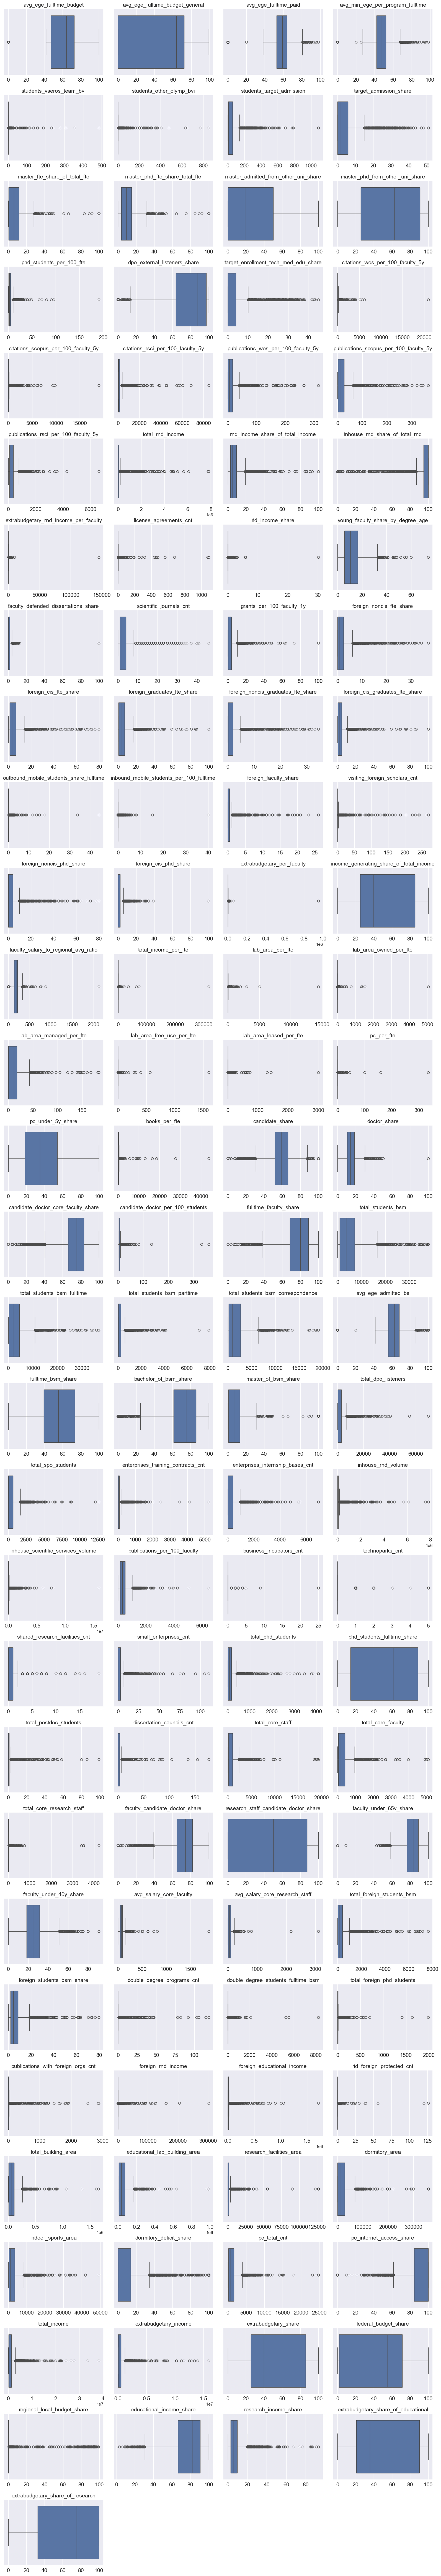

In [15]:
uni_cols_to_plot = uni.columns[:117]
n_cols = 4
n_rows = (len(uni_cols_to_plot) + n_cols - 1) // n_cols

_, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(uni_cols_to_plot):
    sns.boxplot(x=uni[col], ax=axes[i])
    axes[i].set_title(col, fontsize=14)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=14, pad=1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(wspace=0.1, hspace=0.3)

In [16]:
uni.iloc[:, -6:].astype(str).describe()

,university,region,type,site,id,year
count,2760,2760,2760,2760,2760,2760
unique,1507,108,26,1084,833,4
top,Федеральное государственное образовательное бю...,г.Москва,Частные образовательные организации,nan,1742,2015
freq,4,522,779,13,4,712


In [17]:
uni.groupby("year")[uni.columns[-6:-1]].nunique()

,university,region,type,site,id
year,,,,,
2015,712,88,21,707,712
2020,688,96,22,682,688
2021,679,96,21,674,679
2022,681,97,21,681,681


In [ ]:
(uni_region_counts := uni.region.value_counts())

region
г.Москва                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [ ]:
uni.type.value_counts()

type
Частные образовательные организации                                                 779
Министерство науки и высшего образования Российской Федерации                       644
Министерство образования и науки Российской Федерации                               261
Министерство сельского хозяйства Российской Федерации                               215
Муниципалитеты и субъекты РФ                                                        180
Министерство культуры Российской Федерации                                          179
Министерство здравоохранения Российской Федерации                                   137
Министерство просвещения Российской Федерации                                        99
Министерство здравоохранения и социального развития Российской Федерации             46
Министерство спорта Российской Федерации                                             42
Федеральное агентство железнодорожного транспорта                                    33
Правительство Российской Фе

# Заполнение пропусков

In [20]:
uni_new = uni.copy()

In [21]:
def get_uni_samples_with_null(samples=10):
    uni_samples = []
    for uni_id in uni_new.id.head(samples).to_list():
        curr_uni = uni_new[uni_new.id == uni_id]
        curr_uni = curr_uni[["id", "year"] + uni_cols_index_with_null].copy()
        uni_samples.append(curr_uni)
    return pd.concat(uni_samples, ignore_index=True)

In [22]:
get_uni_samples_with_null()

,id,year,citations_wos_per_100_faculty_5y,citations_scopus_per_100_faculty_5y,publications_wos_per_100_faculty_5y,publications_scopus_per_100_faculty_5y
0,2078,2015,926.83,9819.51,66.67,125.20
1,2078,2020,959.85,944.55,53.54,51.63
2,2078,2021,832.39,822.98,62.15,64.03
3,2078,2022,NaN,NaN,NaN,NaN
4,110353,2015,0.00,1.19,0.00,1.19
5,110145,2015,3.42,1.37,0.68,0.68
6,110145,2020,270.45,290.24,26.39,15.83
7,110145,2021,238.23,332.37,9.61,17.29
8,110145,2022,NaN,NaN,NaN,NaN
9,1651,2015,0.00,0.00,0.00,0.00


In [23]:
def fill_missing_values(group):
    target_mask = group["year"] == 2022
    target_rows = group[target_mask]
    other_rows = group[~target_mask]

    if target_rows.empty:
        return group

    if other_rows.empty:
        for col in uni_cols_index_with_null:
            target_rows.loc[:, col] = target_rows[col].fillna(0)
        group.loc[target_mask, :] = target_rows
        return group

    for col in uni_cols_index_with_null:
        temp = other_rows[["year", col]]
        years = temp["year"].values.reshape(-1, 1)
        values = temp[col].values

        if len(years) >= 2:
            model = LinearRegression()
            model.fit(years, values)
            pred = model.predict([[2022]])[0]
        else:
            pred = values[0]

        pred = max(0, pred)
        pred = round(pred, 2)

        target_rows.loc[:, col] = pred

    group.loc[target_mask, :] = target_rows
    return group


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    uni_new = uni_new.groupby("id", group_keys=False).apply(fill_missing_values).reset_index(drop=True)
uni_new[uni_cols_index_with_null].isnull().sum()

citations_wos_per_100_faculty_5y          0
citations_scopus_per_100_faculty_5y       0
publications_wos_per_100_faculty_5y       0
publications_scopus_per_100_faculty_5y    0
dtype: int64

In [24]:
get_uni_samples_with_null()

,id,year,citations_wos_per_100_faculty_5y,citations_scopus_per_100_faculty_5y,publications_wos_per_100_faculty_5y,publications_scopus_per_100_faculty_5y
0,2078,2015,926.83,9819.51,66.67,125.20
1,2078,2020,959.85,944.55,53.54,51.63
2,2078,2021,832.39,822.98,62.15,64.03
3,2078,2022,877.92,0.00,56.26,41.44
4,110353,2015,0.00,1.19,0.00,1.19
5,110145,2015,3.42,1.37,0.68,0.68
6,110145,2020,270.45,290.24,26.39,15.83
7,110145,2021,238.23,332.37,9.61,17.29
8,110145,2022,316.50,394.69,21.12,20.78
9,1651,2015,0.00,0.00,0.00,0.00


# Предобработка данных

## Исправление ошибок в названиях регионов

In [25]:
uni_region_counts.index = uni_region_counts.index.str[:100]
with pd.option_context("display.max_rows", None):
    print(uni_region_counts)

region
г.Москва                                                                                                 522
г.Санкт-Петербург                                                                                        211
Московская область                                                                                        91
Республика Татарстан                                                                                      78
Свердловская область                                                                                      77
Самарская область                                                                                         70
Краснодарский край                                                                                        70
Новосибирская область                                                                                     69
Воронежская область                                                                                       59
Ростовская о

In [26]:
def clean_region(value):
    for reference in reference_regions:
        if value.startswith(reference):
            return reference
    return value


reference_regions = [
    "г.Москва",
    "г.Санкт-Петербург",
    "Московская область",
    "Республика Татарстан",
    "Свердловская область",
    "Самарская область",
    "Краснодарский край",
    "Новосибирская область",
    "Воронежская область",
    "Ростовская область",
    "Челябинская область",
    "Омская область",
    "Волгоградская область",
    "Ставропольский край",
    "Республика Дагестан",
    "Нижегородская область",
    "Пермский край",
    "Республика Башкортостан",
    "Иркутская область",
    "Красноярский край",
    "Хабаровский край",
    "Приморский край",
    "Ярославская область",
    "Алтайский край",
    "Курская область",
    "Республика Северная Осетия-Алания",
    "Кемеровская область",
    "Саратовская область",
    "Удмуртская Республика",
    "Республика Саха (Якутия)",
    "Тверская область",
    "Ивановская область",
    "Томская область",
    "Астраханская область",
    "Рязанская область",
    "Оренбургская область",
    "Смоленская область",
    "Ханты-Мансийский автономный округ",
    "Белгородская область",
    "Тюменская область",
    "Тульская область",
    "Брянская область",
    "Ульяновская область",
    "Пензенская область",
    "Кировская область",
    "Орловская область",
    "Липецкая область",
    "Тамбовская область",
    "Чувашская Республика",
    "Амурская область",
    "Республика Крым",
    "Архангельская область",
    "Вологодская область",
    "Республика Бурятия",
    "Мурманская область",
    "Калужская область",
    "Республика Марий Эл",
    "Калининградская область",
    "Псковская область",
    "Республика Коми",
    "Чеченская Республика",
    "Курганская область",
    "Костромская область",
    "Владимирская область",
    "Карачаево-Черкесская Республика",
    "Забайкальский край",
    "Республика Карелия",
    "Республика Мордовия",
    "Камчатский край",
    "Кабардино-Балкарская Республика",
    "Республика Адыгея",
    "Республика Ингушетия",
    "Сахалинская область",
    "Ленинградская область",
    "Новгородская область",
    "Магаданская область",
    "Республика Алтай",
    "Еврейская автономная область",
    "Республика Хакасия",
    "Республика Калмыкия",
    "Республика Тыва",
    "г.Севастополь",
    "Ингушская Республика"
]

uni_new.region = uni_new.region.apply(lambda x: clean_region(x))
uni_region_counts = uni_new.region.value_counts()

with pd.option_context("display.max_rows", None):
    print(uni_region_counts)

region
г.Москва                             530
г.Санкт-Петербург                    221
Московская область                    94
Свердловская область                  82
Республика Татарстан                  82
Самарская область                     74
Краснодарский край                    70
Новосибирская область                 69
Воронежская область                   59
Ростовская область                    53
Челябинская область                   51
Омская область                        49
Волгоградская область                 48
Ставропольский край                   48
Республика Дагестан                   44
Нижегородская область                 42
Пермский край                         41
Республика Башкортостан               41
Иркутская область                     38
Красноярский край                     34
Хабаровский край                      33
Приморский край                       33
Ярославская область                   32
Алтайский край                        31
Курская о

## Разбиение данных по годам

In [60]:
uni_by_year = {}

for year in uni_new.year.unique():
    uni_year = uni_new[uni_new.year == year].copy()

    uni_year.drop(columns=["university", "site", "id", "year"], inplace=True)
    uni_year.reset_index(drop=True, inplace=True)
    
    uni_by_year[int(year)] = uni_year

for year, uni_year in uni_by_year.items():
    print(year, uni_year.shape[0], sep=" - ")

2015 - 712
2020 - 688
2021 - 679
2022 - 681


## Наивное кодирование (черновик)

In [168]:
uni_dummy = deepcopy(uni_by_year)

for year, uni_year in uni_dummy.items():
    regions_encoder = OneHotEncoder(sparse_output=False)
    regions_dummy = regions_encoder.fit_transform(uni_year[["region"]])
    regions_dummy_df = pd.DataFrame(regions_dummy, columns=regions_encoder.categories_[0])

    types_encoder = OneHotEncoder(sparse_output=False)
    types_dummy = types_encoder.fit_transform(uni_year[["type"]])
    types_dummy_df = pd.DataFrame(types_dummy, columns=types_encoder.categories_[0])

    uni_year = pd.concat([uni_year, regions_dummy_df, types_dummy_df], axis=1)
    uni_dummy[year] = uni_year.drop(columns=["region", "type"])

uni_dummy[2022]

,avg_ege_fulltime_budget,avg_ege_fulltime_budget_general,avg_ege_fulltime_paid,avg_min_ege_per_program_fulltime,students_vseros_team_bvi,students_other_olymp_bvi,students_target_admission,target_admission_share,master_fte_share_of_total_fte,master_phd_fte_share_total_fte,...,Муниципалитеты и субъекты РФ,Правительство Российской Федерации,"Федеральная служба по интеллектуальной собственности, патентам и товарным знакам",Федеральная таможенная служба,Федеральное агентство воздушного транспорта,Федеральное агентство железнодорожного транспорта,Федеральное агентство морского и речного транспорта,Федеральное агентство по рыболовству,Федеральное агентство связи,Частные образовательные организации
0,0.00,0.00,61.28,48.28,0,0,0,0.00,8.34,8.34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,51.69,51.69,51.48,39.26,0,0,0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.00,0.00,55.70,55.70,0,0,0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.00,0.00,0.00,0.00,0,0,0,0.00,100.00,100.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,67.58,67.58,57.65,42.29,0,0,237,36.92,0.06,11.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,66.96,66.96,60.90,47.30,0,0,40,2.48,11.02,12.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
678,63.68,63.68,0.00,53.42,0,0,1,0.68,14.15,17.46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Частотное кодирование

In [61]:
uni_freq = deepcopy(uni_by_year)

for uni_year in uni_freq.values():
    uni_year.region = uni_year.region.map(uni_year.region.value_counts(normalize=True))
    uni_year.type = uni_year.type.map(uni_year.type.value_counts(normalize=True))

uni_freq[2022]

,avg_ege_fulltime_budget,avg_ege_fulltime_budget_general,avg_ege_fulltime_paid,avg_min_ege_per_program_fulltime,students_vseros_team_bvi,students_other_olymp_bvi,students_target_admission,target_admission_share,master_fte_share_of_total_fte,master_phd_fte_share_total_fte,...,extrabudgetary_income,extrabudgetary_share,federal_budget_share,regional_local_budget_share,educational_income_share,research_income_share,extrabudgetary_share_of_educational,extrabudgetary_share_of_research,region,type
0,0.00,0.00,61.28,48.28,0,0,0,0.00,8.34,8.34,...,177176.1,100.00,0.00,0.00,80.76,4.42,100.00,100.00,0.022026,0.286344
1,51.69,51.69,51.48,39.26,0,0,0,0.00,0.00,0.00,...,33047.1,42.82,57.18,0.00,66.01,11.19,34.13,100.00,0.022026,0.286344
2,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,11873.0,97.99,2.01,0.00,97.58,0.00,100.00,0.00,0.011747,0.286344
3,0.00,0.00,55.70,55.70,0,0,0,0.00,0.00,0.00,...,6678.5,100.00,0.00,0.00,68.66,1.53,100.00,100.00,0.030837,0.286344
4,0.00,0.00,0.00,0.00,0,0,0,0.00,100.00,100.00,...,1631848.8,17.07,82.93,0.00,9.09,85.08,9.77,12.17,0.195301,0.286344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,67.58,67.58,57.65,42.29,0,0,237,36.92,0.06,11.10,...,307408.2,21.16,77.96,0.88,81.24,2.50,21.76,53.27,0.011747,0.067548
677,66.96,66.96,60.90,47.30,0,0,40,2.48,11.02,12.01,...,567529.0,27.11,68.85,4.04,58.67,10.97,30.82,28.26,0.011747,0.314244
678,63.68,63.68,0.00,53.42,0,0,1,0.68,14.15,17.46,...,45185.3,22.79,77.21,0.00,96.62,0.63,22.50,0.00,0.011747,0.064611
679,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,...,12682.0,100.00,0.00,0.00,100.00,0.00,100.00,0.00,0.007342,0.286344


## Нормализация

In [169]:
# uni_norm = deepcopy(uni_freq)
uni_norm = deepcopy(uni_dummy)
uni_cols_to_norm = uni_new.columns[:117]

for uni_year in uni_norm.values():
    scaler = MinMaxScaler()
    uni_year[uni_cols_to_norm] = scaler.fit_transform(uni_year[uni_cols_to_norm])

uni_norm[2022]

,avg_ege_fulltime_budget,avg_ege_fulltime_budget_general,avg_ege_fulltime_paid,avg_min_ege_per_program_fulltime,students_vseros_team_bvi,students_other_olymp_bvi,students_target_admission,target_admission_share,master_fte_share_of_total_fte,master_phd_fte_share_total_fte,...,Муниципалитеты и субъекты РФ,Правительство Российской Федерации,"Федеральная служба по интеллектуальной собственности, патентам и товарным знакам",Федеральная таможенная служба,Федеральное агентство воздушного транспорта,Федеральное агентство железнодорожного транспорта,Федеральное агентство морского и речного транспорта,Федеральное агентство по рыболовству,Федеральное агентство связи,Частные образовательные организации
0,0.0000,0.000000,0.625306,0.492653,0.0,0.0,0.000000,0.000000,0.0834,0.0834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.5169,0.521594,0.525306,0.400612,0.0,0.0,0.000000,0.000000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0000,0.000000,0.568367,0.568367,0.0,0.0,0.000000,0.000000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1.0000,1.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,0.6758,0.681937,0.588265,0.431531,0.0,0.0,0.304627,0.724917,0.0006,0.1110,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,0.6696,0.675681,0.621429,0.482653,0.0,0.0,0.051414,0.048694,0.1102,0.1201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
678,0.6368,0.642583,0.000000,0.545102,0.0,0.0,0.001285,0.013352,0.1415,0.1746,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Устранение избыточности данных

In [170]:
def get_cols_with_high_corr(df, threshold):
    corr = df.corr().abs()
    corr_triu = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    corr_pairs = corr_triu.stack().reset_index()
    corr_pairs.columns = ["col1", "col2", "corr"]

    cols_with_high_corr = corr_pairs[corr_pairs["corr"] > threshold].copy()
    cols_with_high_corr.sort_values("corr", ascending=False, inplace=True)

    return cols_with_high_corr.reset_index(drop=True)

In [171]:
uni_cols_with_high_corr = {}

for year, uni_year in uni_norm.items():
    uni_cols_with_high_corr[year] = get_cols_with_high_corr(uni_year, threshold=0.9)

uni_cols_with_high_corr[2022]

,col1,col2,corr
0,income_generating_share_of_total_income,extrabudgetary_share,1.000000
1,rnd_income_share_of_total_income,research_income_share,1.000000
2,total_rnd_income,inhouse_rnd_volume,0.997108
3,inhouse_rnd_volume,inhouse_scientific_services_volume,0.993054
4,total_rnd_income,inhouse_scientific_services_volume,0.990445
5,total_core_staff,total_core_faculty,0.963077
6,avg_ege_fulltime_budget,avg_ege_fulltime_budget_general,0.962754
7,total_building_area,educational_lab_building_area,0.960476
8,extrabudgetary_share,extrabudgetary_share_of_educational,0.958564
9,income_generating_share_of_total_income,extrabudgetary_share_of_educational,0.958564


In [172]:
for year, uni_cols in uni_cols_with_high_corr.items():
    print(year, len(uni_cols), sep=" - ")

2015 - 28
2020 - 23
2021 - 30
2022 - 27


In [173]:
def get_cols_to_drop(df, cols_with_high_corr):
    cols_to_drop = []

    for _, row in cols_with_high_corr.iterrows():
        col1, col2 = row["col1"], row["col2"]

        if col1 in cols_to_drop or col2 in cols_to_drop:
            continue

        if df[col1].var() < df[col2].var():
            cols_to_drop.append(col1)
        else:
            cols_to_drop.append(col2)
    
    return cols_to_drop

In [174]:
uni_cols_to_drop = {}

for year, uni_year in uni_norm.items():
    uni_cols_to_drop[year] = get_cols_to_drop(uni_year, uni_cols_with_high_corr[year])

uni_cols_to_drop[2022]

['extrabudgetary_share',
 'research_income_share',
 'inhouse_rnd_volume',
 'total_rnd_income',
 'total_core_staff',
 'avg_ege_fulltime_budget',
 'total_building_area',
 'income_generating_share_of_total_income',
 'total_income',
 'faculty_candidate_doctor_share',
 'publications_rsci_per_100_faculty_5y',
 'regional_local_budget_share',
 'master_fte_share_of_total_fte',
 'total_students_bsm_fulltime',
 'total_core_faculty',
 'citations_wos_per_100_faculty_5y',
 'pc_per_fte']

In [175]:
for year, uni_cols in uni_cols_to_drop.items():
    print(year, len(uni_cols), sep=" - ")

2015 - 15
2020 - 15
2021 - 18
2022 - 17


In [176]:
uni_clean = deepcopy(uni_norm)

for year, uni_year in uni_clean.items():
    uni_year.drop(columns=uni_cols_to_drop[year], inplace=True)

uni_clean[2022]

,avg_ege_fulltime_budget_general,avg_ege_fulltime_paid,avg_min_ege_per_program_fulltime,students_vseros_team_bvi,students_other_olymp_bvi,students_target_admission,target_admission_share,master_phd_fte_share_total_fte,master_admitted_from_other_uni_share,master_phd_from_other_uni_share,...,Муниципалитеты и субъекты РФ,Правительство Российской Федерации,"Федеральная служба по интеллектуальной собственности, патентам и товарным знакам",Федеральная таможенная служба,Федеральное агентство воздушного транспорта,Федеральное агентство железнодорожного транспорта,Федеральное агентство морского и речного транспорта,Федеральное агентство по рыболовству,Федеральное агентство связи,Частные образовательные организации
0,0.000000,0.625306,0.492653,0.0,0.0,0.000000,0.000000,0.0834,0.6316,0.9762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.521594,0.525306,0.400612,0.0,0.0,0.000000,0.000000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000000,0.568367,0.568367,0.0,0.0,0.000000,0.000000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1.0000,1.0000,0.7823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,0.681937,0.588265,0.431531,0.0,0.0,0.304627,0.724917,0.1110,0.0000,0.2045,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,0.675681,0.621429,0.482653,0.0,0.0,0.051414,0.048694,0.1201,0.1787,0.3558,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
678,0.642583,0.000000,0.545102,0.0,0.0,0.001285,0.013352,0.1746,0.4375,0.3897,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [177]:
for year, uni_year in uni_clean.items():
    print(year, uni_year.shape[1], sep=" - ")

2015 - 203
2020 - 206
2021 - 202
2022 - 203


## Визуализация распределения вузов на плоскости

In [178]:
uni_pca = {}

for year, uni_year in uni_clean.items():
    pca = PCA(n_components=2)
    uni_pca[year] = pca.fit_transform(uni_year)

uni_pca[2022]

array([[ 1.32355124,  0.65144133],
       [ 0.830767  , -0.35858433],
       [ 1.66380646, -0.76548366],
       ...,
       [-0.3303501 , -0.86497877],
       [ 1.73266103, -0.76707115],
       [ 1.561571  , -0.47072328]], shape=(681, 2))

## Разбиение с наивным кодированием

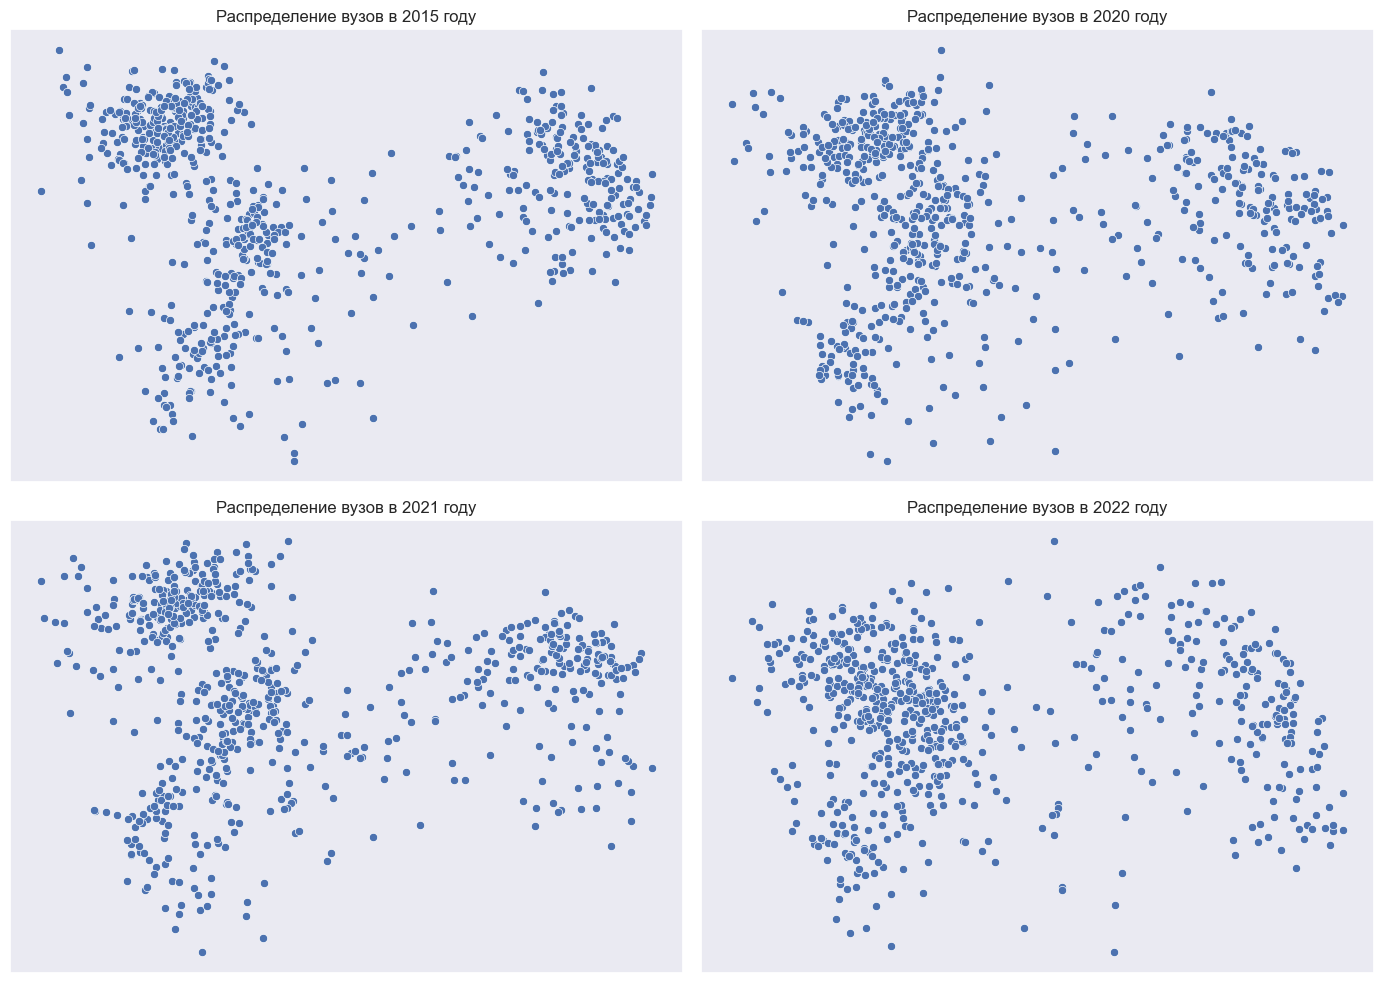

In [179]:
_, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, year, uni_year in zip(range(4), uni_pca.keys(), uni_pca.values()):
    sns.scatterplot(x=uni_year[:, 0], y=uni_year[:, 1], ax=axes[i]) \
        .set(title=f"Распределение вузов в {year} году", xticks=[], yticks=[])

plt.tight_layout()

## Разбиение с частотным кодированием

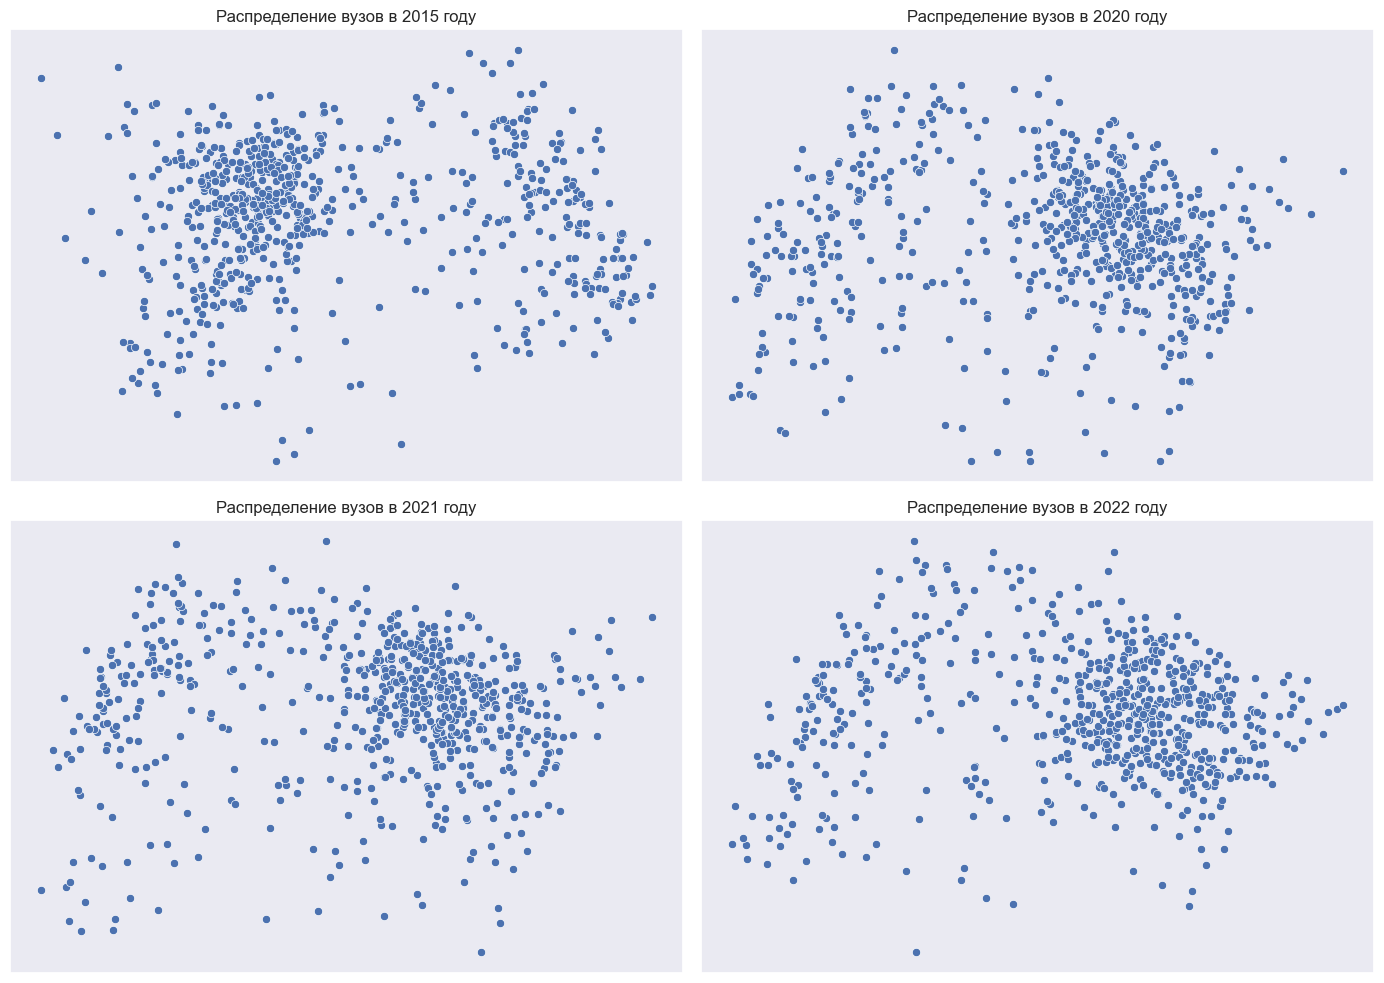

In [162]:
_, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, year, uni_year in zip(range(4), uni_pca.keys(), uni_pca.values()):
    sns.scatterplot(x=uni_year[:, 0], y=uni_year[:, 1], ax=axes[i]) \
        .set(title=f"Распределение вузов в {year} году", xticks=[], yticks=[])

plt.tight_layout()

# Кластеризация